#### Bayesian Inference with Discrete Parameter and Discrete Observation

This scenario demonstrates Bayesian inference when both the parameter (Theta, our unknown) and the observed data (X) are discrete. We define:

- **Parameter Space ($\Theta$)**: The possible values our unknown parameter can take.
- **Prior Distribution $P(\Theta)$**: Our initial belief about the probabilities of each Theta value before observing any data.
- **Likelihood $P(X | \Theta)$**: The probability of observing our data (X) given each possible value of $\Theta$.
- **Posterior Distribution $P(\Theta | X)$**: Update our beliefs about Theta after observing X, using Bayes' Theorem.

**Scenario**: Imagine we have a coin, but we don't know if it's fair. We suspect its probability of landing heads (Theta) could be one of a few discrete values (e.g., 0.2, 0.5, 0.8). We then flip the coin a few times and observe the number of heads (X).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Parameter Space (Theta)
# Possible probabilities of getting a Head (our unknown parameter)
theta_values = np.array([0.2, 0.5, 0.8])

# Define the Prior Distribution P(Theta)
# Our initial belief: we think a fair coin is most likely, but also possible it's biased.
prior_theta = np.array([0.2, 0.6, 0.2]) # Sum must be 1

print(f"Theta values: {theta_values} \n"
f"Prior P(Theta): {prior_theta}")
assert np.isclose(np.sum(prior_theta), 1), "Prior probabilities must sum to 1."

Theta values: [0.2 0.5 0.8] 
Prior P(Theta): [0.2 0.6 0.2]


#### Least Mean Squares (LMS) Algorithm

The **LMS algorithm** is an adaptive filter that is widely used in various applications, particularly in signal processing and machine learning for tasks like noise cancellation, echo cancellation, and linear prediction. It's a type of stochastic gradient descent algorithm.

The LMS algorithm iteratively updates the filter coefficients (weights) to minimize the mean square error (MSE) between the desired output and the actual output of the filter. It does this by taking small steps in the direction opposite to the gradient of the instantaneous squared error.

Here's a breakdown of the key components:
- **Input Signal ($x(n)$)**: The data fed into the filter at time $n$.
- **Filter Coefficients ($w(n)$)**: The weights of the filter, which are adjusted over time.
- **Filter Output ($y(n)$)**: The output produced by the filter, calculated as the dot product of the input signal and the filter coefficients: $y(n) = w^T(n)x(n)$.
- **Desired Output ($d(n)$)**: The target or reference signal that the filter is trying to match.
- **Error Signal ($e(n)$)**: The difference between the desired output and the filter output: $e(n) = d(n) - y(n)$.
- **Weight Update Rule**: The core of the LMS algorithm. The weights are updated at each step using the following formula:
    $$ w(n+1) = w(n) + 2\mu e(n)x(n) $$

    Where:
    *   $w(n+1)$ are the updated weights.
    *   $w(n)$ are the current weights.
    *   $\mu$ (mu) is the **step size** (or learning rate), a small positive constant that controls the stability and convergence rate of the algorithm. A larger $\mu$ leads to faster but potentially unstable convergence, while a smaller $\mu$ leads to slower but more stable convergence.

Characteristics:
*   **Simplicity**: It's computationally inexpensive and easy to implement.
*   **Adaptive**: It can continuously adjust its weights to changing input signal characteristics.
*   **Gradient Descent**: It uses an approximation of the gradient of the error surface.

LMS is particularly useful in situations where the characteristics of the signal or noise are unknown or changing over time, making a fixed filter design impractical. It's often employed in digital communication systems, control systems, and machine learning for tasks like linear regression or prediction where online updates are desirable.

While the current context is Bayesian Inference, we give a simple Python example of to implement a basic LMS filter for a simple signal.

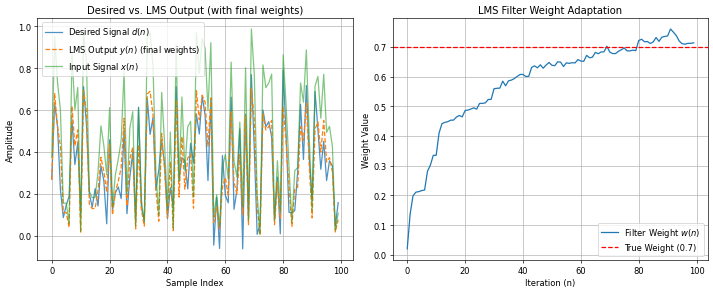

True weight: 0.7000 
Final LMS estimated weight: 0.7140


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data for demonstration
# True system: d(n) = 0.5*x(n) + noise(n)
np.random.seed(42)
N_samples = 100 # Number of data points

# Input signal (e.g., random noise)
x = np.random.rand(N_samples)

# Desired signal (a noisy version of a simple linear system)
true_weight = 0.7 # The 'true' parameter we want to estimate
noise = 0.1 * np.random.randn(N_samples) # Add some Gaussian noise
d = true_weight * x + noise

# LMS Algorithm Implementation

# Initialize filter coefficients (weights)
w = np.zeros(1) # We expect a single weight for y = w*x

# Step size (learning rate)
mu = 0.1 # This needs to be tuned; too large -> unstable, too small -> slow

# Store values for plotting/analysis
errors = []
weights_history = []

for n in range(N_samples):
    y = w[0] * x[n] # Filter output
    e = d[n] - y # Error signal
    w[0] = w[0] + 2 * mu * e * x[n] # Update weights (LMS rule)
    errors.append(e) # Store for analysis
    weights_history.append(w[0])

**Define the Likelihood $P(X |\Theta)$**

Let's say we flip the coin $N$ times and observe $k$ heads. The likelihood of observing $k$ heads given a specific theta (probability of heads) follows a Binomial distribution.

In [ ]:
from scipy.special import comb

# Observed data: N coin flips, k heads
N_flips = 10
k_heads = 7

# Likelihood function: P(X=k_heads | Theta)
def likelihood(theta, N, k):
    # Binomial probability mass function
    return comb(N, k) * (theta**k) * ((1 - theta)**(N - k))

# Calculate likelihood for each theta value
likelihood_x_given_theta = np.array([likelihood(t, N_flips, k_heads) for t in theta_values])

Observed: 7 heads in 10 flips.
Likelihood P(X=7|Theta): [0.00078643 0.1171875  0.20132659]


**Calculate the Posterior Distribution P(Theta | X)**

Using Bayes' Theorem
- $ P(\text{Theta} | X) = \frac{P(X | \text{Theta}) \times P(\text{Theta})}{P(X)} $

Where $P(X)$ is the evidence (or marginal likelihood), and it acts as a normalizing constant
- $ P(X) = \sum_{\text{all Theta}} P(X | \text{Theta}) \times P(\text{Theta}) $

So, the posterior is proportional to Likelihood * Prior.

In [ ]:
# Calculate the unnormalized posterior
unnormalized_posterior = likelihood_x_given_theta * prior_theta

# Calculate the evidence P(X) (normalizing constant)
evidence = np.sum(unnormalized_posterior)

# Calculate the normalized posterior
posterior_theta = unnormalized_posterior / evidence

Unnormalized Posterior: [0.00015729 0.0703125  0.04026532]
Evidence P(X): 0.11073510479999998
Posterior P(Theta|X): [0.00142038 0.63496124 0.36361837]


**Maximum A Posteriori (MAP) Rule**

In the context of Bayesian inference, the MAP estimate is simply the mode of the posterior distribution.

Mathematically, if we have a parameter $\theta$ and observed data $X$, the MAP estimate $\hat{\theta}_{MAP}$ is given by $ \hat{\theta}_{MAP} = \underset{\theta}{\operatorname{argmax}} P(\theta | X) $

Using Bayes' Theorem, this can also be written as $ \hat{\theta}_{MAP} = \underset{\theta}{\operatorname{argmax}} \frac{P(X | \theta) \times P(\theta)}{P(X)}$. Since $P(X)$ is a constant with respect to $\theta$, we can simplify it to $ \hat{\theta}_{MAP} = \underset{\theta}{\operatorname{argmax}} P(X | \theta) \times P(\theta)$. This means the MAP estimate is the value of $\theta$ that maximizes the product of the likelihood and the prior. When the prior is uniform, MAP estimation reduces to MLE.

**Calculating MAP Estimate** for the Coin Flip Example

The MAP estimate for our coin's probability of heads (Theta) using the posterior probabilities we calculated earlier.

In [ ]:
# Recall our theta_values and posterior_theta
# theta_values = np.array([0.2, 0.5, 0.8])
# posterior_theta = np.array([0.00142038, 0.63496124, 0.36361837])

# Find the index of the maximum posterior probability
map_index = np.argmax(posterior_theta)

# Get the theta value corresponding to the maximum posterior probability
map_estimate = theta_values[map_index]
map_probability = posterior_theta[map_index]

# For comparison, let's also quickly find the MLE (Maximum Likelihood Estimate)
# The MLE is the theta that maximizes the likelihood P(X|Theta)
# likelihood_x_given_theta = np.array([0.00078643, 0.1171875, 0.20132659])
mle_index = np.argmax(likelihood_x_given_theta)
mle_estimate = theta_values[mle_index]

Theta values: [0.2 0.5 0.8] 
Posterior P(Theta|X): [0.00142038 0.63496124 0.36361837] 

Maximum A Posteriori (MAP) estimate for Theta: 0.5 
With a posterior probability of: 0.6350

Maximum Likelihood Estimate (MLE) for Theta: 0.8


Plot the prior, likelihood, and posterior distributions to see how our belief about $\Theta$ changes after observing the data.

The plot illustrates how the observed data (likelihood) shifts our prior beliefs to form the posterior distribution. In this case, observing 7 heads out of 10 flips makes us lean more towards Theta = 0.8, as reflected in the higher posterior probability for that value.

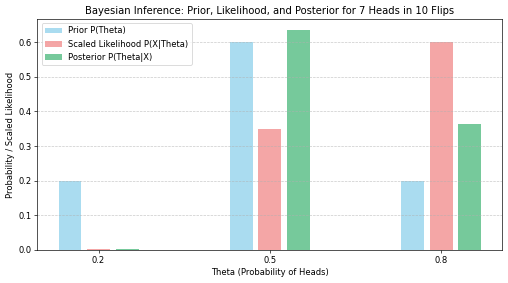

In [ ]:
f'Bayesian Inference: Prior, Likelihood, and Posterior for {k_heads} Heads in {N_flips} Flips'

#### Bayesian Inference with Discrete Parameter and Continuous Observation

This scenario demonstrates Bayesian inference with discrete parameter space, continuous observation r.v. X.  

We define the discrete parameter space, synthetic continuous data based on a true parameter, uniform prior probabilities. We derive Gaussian likelihood function, compute posterior probabilities, and determine the Maximum A Posteriori (MAP) and Least Mean Squares (LMS) estimates. Finally, plot the prior, normalized likelihood, and posterior distributions, marking the MAP and LMS estimates.

**Data Generation**

Define a discrete parameter space, choose a true parameter, define the characteristics of a continuous observation (e.g., standard deviation for a Gaussian distribution), and use synthetic continuous data based on the true parameter.


In [ ]:
import numpy as np

# Define a discrete parameter space (e.g., possible mean values for a Gaussian distribution)
parameter_space = np.array([50, 55, 60, 65, 70])

# Choose a 'true' parameter value from the discrete parameter space
true_parameter = 60

Defined discrete parameter space: [50 55 60 65 70]
Chosen true parameter: 60


**Define Observation Characteristics and Synthetic Data**

We define the characteristics of our continuous observations. For Gaussian distribution, this primarily involves specifying the standard deviation. After defining this, we generate a set of synthetic data points using our chosen true_parameter as the mean and the specified standard deviation. This simulates real-world data collection where observations are noisy measurements around a true underlying parameter.

In [ ]:
# Define the standard deviation for the Gaussian distribution
standard_deviation = 5

# Define the number of data points to generate
num_observations = 100

# Generate synthetic continuous data based on the true parameter and standard deviation
synthetic_data = np.random.normal(loc=true_parameter, scale=standard_deviation, size=num_observations)

Standard deviation for observations: 5 
Number of synthetic observations: 100 
First 5 synthetic data points: [59.56210698 54.27202569 65.28220617 58.85489752 52.05535491] 
Mean of generated data: 59.84 
Standard deviation of generated data: 5.76


Show the frequency of data points within different bins and help observe if the data generally centers around the true_parameter with the specified standard_deviation, as expected for a Gaussian distribution.

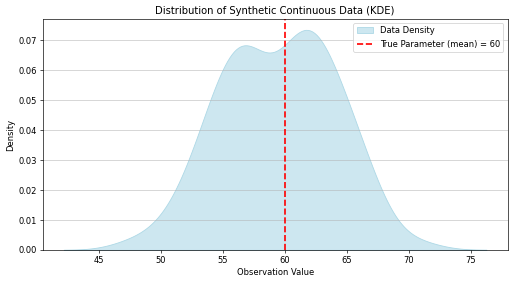

In [ ]:
# Define a discrete parameter space (e.g., possible mean values for a Gaussian distribution)
parameter_space = np.array([50, 55, 60, 65, 70])

# Choose a 'true' parameter value from the discrete parameter space
true_parameter = 60
# Define the standard deviation for the Gaussian distribution
standard_deviation = 5
# Define the number of data points to generate
num_observations = 100

# Generate synthetic continuous data based on the true parameter and std
synthetic_data = np.random.normal(loc=true_parameter, scale=standard_deviation, size=num_observations)

**Define Prior and Likelihood**

Define uniform prior probabilities for each discrete parameter value. Implement the likelihood function for the continuous observations given each discrete parameter value (e.g., using a Gaussian pdf).

In [ ]:
num_parameters = len(parameter_space)
prior_probabilities = np.ones(num_parameters) / num_parameters

Number of parameters in space: 5 
Uniform prior probabilities: [0.2 0.2 0.2 0.2 0.2] 
Sum of prior probabilities: 1.0


**Implement the Likelihood Function (Gaussian PDF)**

To perform Bayesian inference with continuous observations, we need likelihood function. This function quantifies how probable our observed data is, given a particular parameter value from our discrete parameter space. For continuous data assumed to be drawn from a Gaussian distribution, the likelihood for a single observation is given by the pdf of the Gaussian distribution. For multiple independent observations, the total likelihood is the product of individual likelihoods.

In [ ]:
from scipy.stats import norm

# Define the Gaussian likelihood function
def gaussian_likelihood(observation, mean, std_dev):
    return norm.pdf(observation, loc=mean, scale=std_dev)

Gaussian likelihood function defined.


In [ ]:
likelihoods_per_parameter = []

for param_mean in parameter_space:
    # Calculate likelihood for all data points for the current parameter mean
    likelihood_for_param = gaussian_likelihood(synthetic_data, param_mean, standard_deviation)
    likelihoods_per_parameter.append(likelihood_for_param)

# Convert to a NumPy array for easier manipulation
likelihoods_per_parameter = np.array(likelihoods_per_parameter)

Shape of likelihoods per parameter: (5, 100)
First 5 likelihoods for the first parameter: [0.01281609 0.05538865 0.00074711 0.01662977 0.07332409] 
First 5 likelihoods for the true parameter (60): [0.07948305 0.04139603 0.04566558 0.07772319 0.02257925]


**Posterior, MAP, and LMS**

Calculate the posterior probabilities for each discrete parameter value using Bayes' theorem. Determine the Maximum A Posteriori (MAP) estimate and the Least Mean Squares (LMS) estimate for the parameter from the posterior distribution.


In [ ]:
# Calculate the total likelihood of all synthetic_data observations for each parameter
# by multiplying individual likelihoods. Use log-likelihoods to avoid underflow
log_total_likelihoods = np.sum(np.log(likelihoods_per_parameter), axis=1)
# Exponentiate to get the total likelihoods (product of individual likelihoods)
total_likelihoods = np.exp(log_total_likelihoods)
# Compute the unnormalized posterior probabilities
unnormalized_posterior = total_likelihoods * prior_probabilities
# Calculate evidence (marginal likelihood) as the sum of unnormalized posteriors
evidence = np.sum(unnormalized_posterior)
# Normalize the unnormalized posterior prob. to get the final posterior prob.
posterior_probabilities = unnormalized_posterior / evidence

Log total likelihoods for each parameter: [-512.77231196 -365.96910594 -319.16589992 -372.3626939  -525.55948788] 
Total likelihoods for each parameter: [2.02215501e-223 1.15248888e-159 2.44349162e-139 1.92724432e-162
 5.65476424e-229]
Unnormalized posterior probabilities: [4.04431002e-224 2.30497776e-160 4.88698324e-140 3.85448863e-163
 1.13095285e-229]
Evidence (normalizing constant): 4.886983239734466e-140
Normalized posterior probabilities: [8.27567810e-85 4.71656572e-21 1.00000000e+00 7.88725568e-24
 2.31421471e-90]
Sum of posterior probabilities: 1.0


**Determine MAP and LMS Estimates**

With the posterior probabilities calculated, we can now find our best estimates for the true parameter. The MAP estimate is the parameter value that has the highest posterior probability. The LMS estimate, also known as the posterior mean, is the expected value of the parameter given the data, which is calculated as a weighted average of the parameter space using the posterior probabilities as weights. The LMS estimate can be a more robust estimator as it considers the entire posterior distribution, not just the peak.

In [ ]:
import numpy as np

# Identify the Maximum A Posteriori (MAP) estimate
# The MAP estimate is the parameter value with the highest posterior probability.
map_index = np.argmax(posterior_probabilities)
map_estimate = parameter_space[map_index]

# Calculate the Least Mean Squares (LMS) estimate (posterior mean)
# The LMS estimate is the weighted average of the parameter space using posterior probabilities as weights.
lms_estimate = np.sum(parameter_space * posterior_probabilities)

Maximum A Posteriori (MAP) estimate: 60
Least Mean Squares (LMS) estimate: 60.00


Plotting the prior, likelihood (normalized for comparison), and posterior distributions in a single plot. Clearly mark the MAP and LMS estimates on the plot using vertical lines with legends.


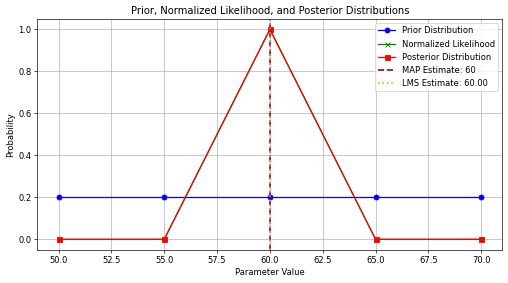

In [ ]:
''' Prior, Normalized Likelihood, and Posterior Distributions '''

### Bayesian Inference with Continuous Parameter and Continuous Observation

**Bayesian inference for a continuous parameter $\Theta$ given a continuous observation X** involves defining the prior and likelihood distributions, computing the posterior distribution,and determining MAP and LMS estimates.

**Define the Continuous Parameter Theta**
- Let's choose $\Theta$ as the true mean of a process. We assume that $\Theta$ can take any real value. For example, let's say $\Theta$ represents the average temperature in a region, which typically falls between -20 and 40 degrees Celsius. However, for a more general case, we can assume $\Theta$ can be any real number.

**Define the Continuous Observation X**
- Let's choose $X$ as a single observation from a process. The range for $X$ will depend on the nature of the observation. For instance, if $X$ is a temperature reading, its range might be similar to $\Theta$. If $X$ is a measurement like height or weight, it would be non-negative. For simplicity, and aligning with the idea that $\Theta$ is a mean, let's assume $X$ can also be any real number, representing a single measurement from the process whose true mean is $\Theta$.

**Define the Conditional Probability Distribution of X given Theta (Likelihood Model)**
- Let's assume that the observation $X$ follows a Normal distribution with a mean equal to $\Theta$ and a known standard deviation. For this example, let's set the standard deviation to $\sigma = 1$. This is a common and tractable choice for illustrating Bayesian inference.

The probability density function (PDF)  $ f(x | \theta, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \theta)^2}{2\sigma^2}\right) $

In [ ]:
import numpy as np
from scipy.stats import norm

# Define the known standard deviation for the likelihood model
sigma = 1.0

def normal_likelihood_pdf(x, theta, sigma=sigma):
    """Calculates the PDF of a Normal distribution for observation x given mean theta.

    Args:
        x (float): The observed data point.
        theta (float): The true mean of the process (parameter).
        sigma (float): The known standard deviation of the observation.

    Returns:
        float: The probability density at x given theta.
    """
    return norm.pdf(x, loc=theta, scale=sigma)

Normal likelihood PDF function defined with sigma = 1.0.


**Choose a specific numerical value for the observed data point, x_obs**

Let's assume we have made an observation from the process. We need a specific value for x_obs to proceed with the Bayesian inference. For example, let's set x_obs = 2.5.

**Define Prior Distribution**

Define a prior pdf for the continuous parameter $\Theta$ over its defined range.


In [ ]:
# Choose a Normal distribution as the prior for Theta
# Define specific numerical values for mu_prior and sigma_prior
mu_prior, sigma_prior = 0.0, 3.0

def normal_prior_pdf(theta, mu=mu_prior, sigma=sigma_prior):
    return norm.pdf(theta, loc=mu, scale=sigma)

Normal prior PDF function defined with mu_prior = 0.0 and sigma_prior = 3.0.


**Likelihood Function**

For a given continuous observation x_obs, define the likelihood function P(x_obs | Theta) as a function of Theta.


In [ ]:
x_obs = 2.5

def likelihood_function(theta):
    return normal_likelihood_pdf(x_obs, theta)

Observed data point (x_obs): 2.5
Likelihood function defined using x_obs and normal_likelihood_pdf.


**Posterior Distribution**

Numerically compute the posterior probability density function $P(\Theta | x_obs)$ by multiplying the prior PDF by the likelihood function and then normalizing the result. This will involve numerical integration for normalization.

**Define Range for $\Theta$**

We need a reasonable range of $\Theta$ values to compute the distributions over. This range should be wide enough to capture the significant parts of both the prior and the likelihood.

**Calculate Prior and Likelihood for Each Theta**

We use the previously defined normal_prior_pdf and likelihood_function to get the prior probability and likelihood for each Theta value in our defined range.

**Compute Unnormalized Posterior**

The unnormalized posterior is proportional to the product of the prior and the likelihood: $P(\text{Theta}, x_{\text{obs}}) = P(x_{\text{obs}} | \text{Theta}) * P(\text{Theta})$.

**Normalize the Posterior**
To normalize the posterior, we divide the unnormalized posterior by the marginal likelihood, $P(x_{\text{obs}})$. The marginal likelihood is the integral of the unnormalized posterior over all possible values of Theta. We will use numerical integration (e.g., np.trapz) to approximate this integral.

In [ ]:
# Define a reasonable range of Theta values for computation.
# Using a range that covers several standard deviations around both the prior mean and the observed data point.
# The prior mean is mu_prior = 0.0, sigma_prior = 3.0
# The observed data x_obs = 2.5, likelihood sigma = 1.0 (implicitly from normal_likelihood_pdf)
# A range from -10 to 10 with a good number of points should be sufficient.
theta_min, theta_max, num_points = -10.0, 10.0, 500
theta_values = np.linspace(theta_min, theta_max, num_points)

# For each Theta value, calculate the prior PDF and the likelihood.
# Vectorize the functions for efficiency
prior_pdf_values = np.array([normal_prior_pdf(t) for t in theta_values])
likelihood_values = np.array([likelihood_function(t) for t in theta_values])

# Compute the unnormalized posterior PDF.
unnormalized_posterior = prior_pdf_values * likelihood_values

# Numerically normalize the posterior distribution.
marginal_likelihood = np.trapezoid(unnormalized_posterior, theta_values)
posterior_pdf_values = unnormalized_posterior / marginal_likelihood

Theta range defined from -10.0 to 10.0 with 500 points. 
Unnormalized posterior computed. 
Marginal likelihood (normalization constant): 0.0923 
Normalized posterior PDF computed.


**MAP and LMS Estimates**

Determine MAP estimate by finding the value of $\Theta$ that maximizes the posterior PDF. Calculate LMS estimate by computing the expected value of Theta under the posterior distribution using numerical integration.


In [ ]:
# Find the index of the maximum value in the posterior_pdf_values array
max_posterior_index = np.argmax(posterior_pdf_values)

# Retrieve the corresponding theta_value for the MAP estimate
map_estimate = theta_values[max_posterior_index]

# LMS estimate (expected value of Theta) using numerical integration
# E[Theta] = integral(Theta * P(Theta | x_obs) dTheta)
lms_estimate = np.trapezoid(theta_values * posterior_pdf_values, theta_values)

Maximum A Posteriori (MAP) Estimate for Theta: 2.2645 
Least Mean Squares (LMS) Estimate for Theta: 2.2500


**Distributions and Estimates**

Display the prior PDF, the likelihood function (scaled appropriately for comparison), and the posterior PDF. Add markers or vertical lines to indicate the MAP and LMS estimates on the posterior distribution.

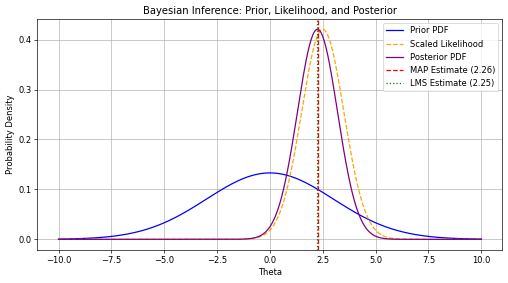

In [ ]:
''' Bayesian Inference: Prior, Likelihood, and Posterior '''

The observation x_obs = 2.5 significantly updated the belief about Theta, shifting the posterior distribution's peak from the prior mean of 0.0 towards the observed data point. The posterior distribution is narrower than the prior, reflecting reduced uncertainty about Theta after incorporating the observation.

The close proximity of the MAP (2.2645) and LMS (2.2500) estimates suggests that the posterior distribution is roughly symmetrical around its peak, indicating a well-behaved posterior that is not heavily skewed.
